# Multi-Model Error Analysis Comparison

This notebook compares error analysis results across **8 models** on the CEX benchmark:
- DeepSeek Chat
- Mistral Small 3.1 24B
- Google Gemma 27B
- Qwen3-VL 32B
- Qwen3-VL 30B-A3B
- Qwen3-VL 8B
- Qwen3-VL 4B
- GROBID Baseline

All models are analyzed on the `extraction_and_parsing_m1` task.

## Updated Terminology

Error classification uses **neutral terminology**:
- **Minor Error**: Low similarity (30-70%) - some fields wrong
- **Major Error**: Very low similarity (<30%) - severe extraction failure
- **Correct**: High similarity (≥70%)

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11

## 1. Load Data for All Models

In [9]:
# Load detailed_failures.csv for all 8 models (ordered: DeepSeek, Mistral, Gemma, Qwen series, GROBID)
all_models = {
    'deepseek': pd.read_csv('outputs/cex/deepseek/detailed_failures.csv'),
    'mistral_small': pd.read_csv('outputs/cex/mistral_small/detailed_failures.csv'),
    'gemma_27b': pd.read_csv('outputs/cex/gemma_27b/detailed_failures.csv'),
    'qwen_32b': pd.read_csv('outputs/cex/qwen_32b/detailed_failures.csv'),
    'qwen_30b_a3b': pd.read_csv('outputs/cex/qwen_30b_a3b/detailed_failures.csv'),
    'qwen_8b': pd.read_csv('outputs/cex/qwen_8b/detailed_failures.csv'),
    'qwen_4b': pd.read_csv('outputs/cex/qwen_4b/detailed_failures.csv'),
    'grobid': pd.read_csv('outputs/cex/grobid/detailed_failures.csv')
}

model_names = ['DeepSeek', 'Mistral', 'Gemma-27B', 'Qwen-32B', 'Qwen-30B-A3B', 'Qwen-8B', 'Qwen-4B', 'GROBID']

print(f"✓ Loaded data for {len(all_models)} models")
for model_key, df in all_models.items():
    print(f"  - {model_key}: {len(df)} documents")

✓ Loaded data for 8 models
  - deepseek: 333 documents
  - mistral_small: 211 documents
  - gemma_27b: 334 documents
  - qwen_32b: 299 documents
  - qwen_30b_a3b: 234 documents
  - qwen_8b: 239 documents
  - qwen_4b: 232 documents
  - grobid: 112 documents


## 2. Visualization 1: Reference-Level Error Distribution (Percentages)

**Purpose**: Compare all models showing the **percentage distribution** of each error type at the reference level.

This visualization shows:
- Percentage of structurally failed extractions
- Percentage of minor errors (30-70% similarity)
- Percentage of major errors (<30% similarity)
- Percentage of correct references extracted

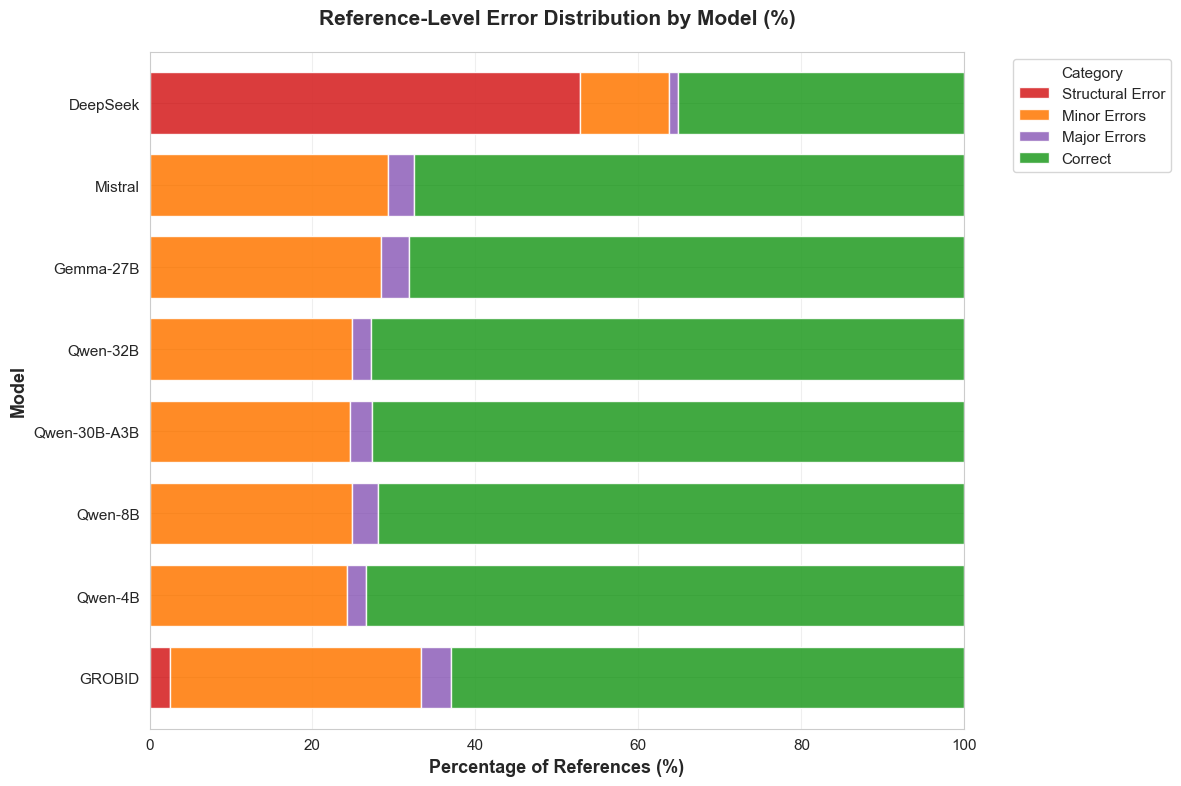


Reference-Level Statistics (Percentages):
Category      Structural Error  Minor Errors  Major Errors  Correct
Model                                                              
GROBID                    2.55         30.80          3.60    63.06
Qwen-4B                   0.00         24.28          2.30    73.42
Qwen-8B                   0.00         24.86          3.14    71.99
Qwen-30B-A3B              0.00         24.60          2.65    72.75
Qwen-32B                  0.00         24.87          2.32    72.81
Gemma-27B                 0.00         28.39          3.40    68.21
Mistral                   0.00         29.29          3.16    67.55
DeepSeek                 52.83         10.90          1.13    35.13


In [14]:
# Calculate reference-level counts and convert to percentages
ref_data = []

for model_name, (model_key, df) in zip(model_names, all_models.items()):
    # Filter to extraction_and_parsing task only
    task_df = df[df['task'] == 'extraction_and_parsing']
    
    # Structural errors: count ground truth refs from structural_error documents
    structural_err = task_df[task_df['failure_category'] == 'structural_error']['gt_ref_count'].sum()
    minor_err = task_df['minor_error_count'].sum()
    major_err = task_df['major_error_count'].sum()
    correct = task_df['correct_count'].sum()
    total = structural_err + minor_err + major_err + correct
    
    if total > 0:
        ref_data.extend([
            {'Model': model_name, 'Category': 'Correct', 'Percentage': correct / total * 100},
            {'Model': model_name, 'Category': 'Major Errors', 'Percentage': major_err / total * 100},
            {'Model': model_name, 'Category': 'Minor Errors', 'Percentage': minor_err / total * 100},
            {'Model': model_name, 'Category': 'Structural Error', 'Percentage': structural_err / total * 100}
        ])

ref_df = pd.DataFrame(ref_data)

# Create horizontal stacked bar chart
fig, ax = plt.subplots(figsize=(12, 8))

# Use distinct, colorblind-friendly colors
colors = {'Structural Error': '#d62728',   # Strong red (most severe)
          'Minor Errors': '#ff7f0e',       # Bright orange
          'Major Errors': '#9467bd',       # Purple (very distinct)
          'Correct': '#2ca02c'}            # Green (positive)

# Pivot for horizontal stacking
pivot_df = ref_df.pivot(index='Model', columns='Category', values='Percentage')
pivot_df = pivot_df[['Structural Error', 'Minor Errors', 'Major Errors', 'Correct']]

# Reindex to enforce correct model order (reversed for horizontal bars - DeepSeek at top)
pivot_df = pivot_df.reindex(model_names[::-1])

# Create horizontal bars
pivot_df.plot(kind='barh', stacked=True, color=[colors[c] for c in pivot_df.columns], 
              ax=ax, width=0.75, alpha=0.9)

ax.set_xlabel('Percentage of References (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Model', fontsize=13, fontweight='bold')
ax.set_title('Reference-Level Error Distribution by Model (%)', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
ax.set_xlim(0, 100)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/cex/multi_model_comparison/reference_level_comparison.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("\nReference-Level Statistics (Percentages):")
print(pivot_df.round(2))

## 3. Visualization 2: Performance by Document Category (Red-Green Heatmap)

**Purpose**: Show reference-level accuracy for each model across different CEX categories.

This heatmap reveals:
- Which categories are consistently harder across all models
- Whether GROBID excels in specific domains
- Model-specific strengths and weaknesses by document type

**Color scheme**: Red = Low accuracy, Green = High accuracy

**Note**: Categories marked with `**` are Humanities subjects.

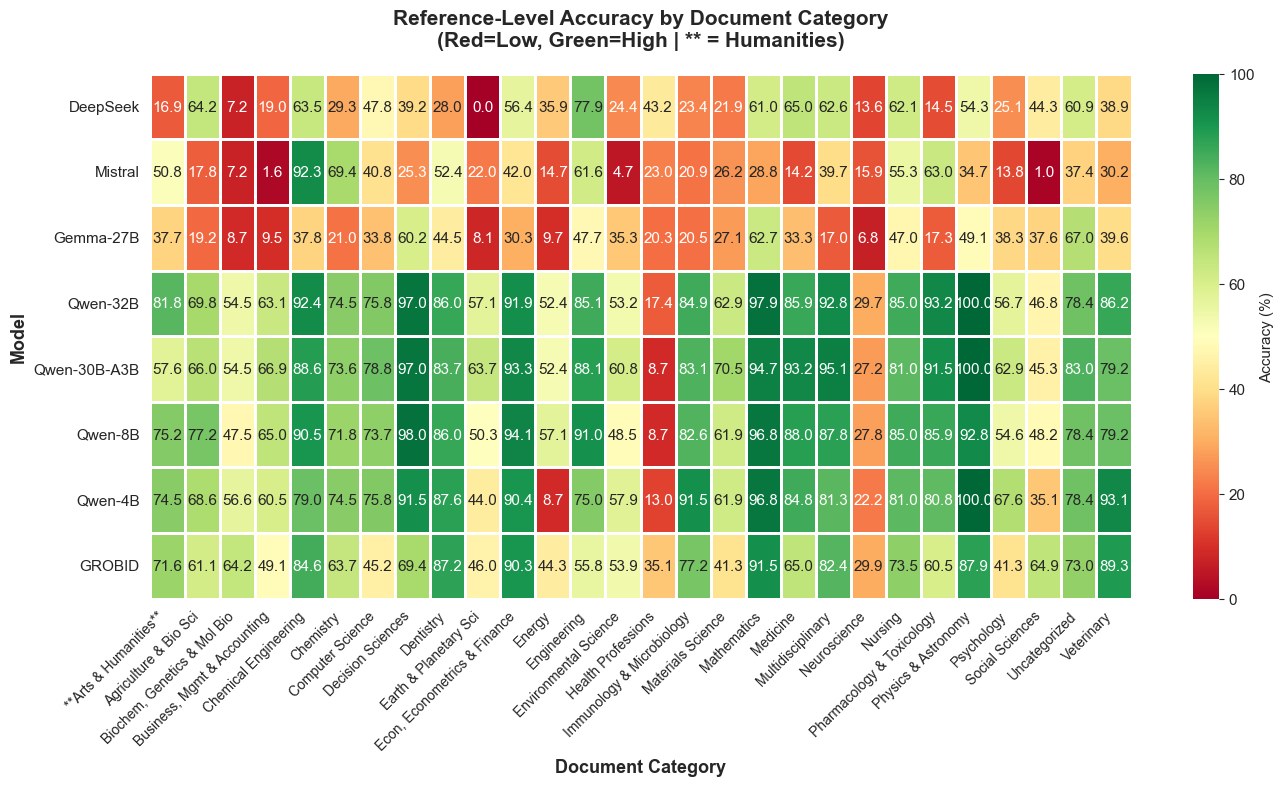


Category Performance Statistics (Accuracy %):
Category      **Arts & Humanities**  Agriculture & Bio Sci  \
Model                                                        
DeepSeek                      16.95                  64.15   
Mistral                       50.85                  17.78   
Gemma-27B                     37.71                  19.17   
Qwen-32B                      81.75                  69.81   
Qwen-30B-A3B                  57.63                  66.04   
Qwen-8B                       75.18                  77.17   
Qwen-4B                       74.45                  68.55   
GROBID                        71.61                  61.14   

Category      Biochem, Genetics & Mol Bio  Business, Mgmt & Accounting  \
Model                                                                    
DeepSeek                             7.17                        18.97   
Mistral                              7.17                         1.64   
Gemma-27B                           

In [11]:
# Map category codes to proper names (** = Humanities)
category_mapping = {
    'ART-HUM': '**Arts & Humanities**',          # HUMANITIES
    'AGR-BIO-SCI': 'Agriculture & Bio Sci',
    'BIO-GEN-MOL': 'Biochem, Genetics & Mol Bio',
    'BUS-MAN-ACC': 'Business, Mgmt & Accounting',
    'CHE-ENG': 'Chemical Engineering',
    'CHEM': 'Chemistry',
    'COM-SCI': 'Computer Science',
    'DEC-SCI': 'Decision Sciences',
    'DEN': 'Dentistry',
    'EAR-PLA-SCI': 'Earth & Planetary Sci',
    'ECO-ECO-FIN': 'Econ, Econometrics & Finance',
    'ENE': 'Energy',
    'ENG': 'Engineering',
    'ENV-SCI': 'Environmental Science',
    'HEA-PRO': 'Health Professions',
    'IMM-MIC': 'Immunology & Microbiology',
    'MAT-SCI': 'Materials Science',
    'MATH': 'Mathematics',
    'MED': 'Medicine',
    'MUL': 'Multidisciplinary',
    'NEU': 'Neuroscience',
    'NUR': 'Nursing',
    'PHA-TOX-PHA': 'Pharmacology & Toxicology',
    'PHY-AST': 'Physics & Astronomy',
    'PSY': 'Psychology',
    'SOC-SCI': 'Social Sciences',
    'VET': 'Veterinary',
    'z_notes_test': 'Uncategorized'
}

# Calculate reference-level accuracy by category
accuracy_data = []

for model_name, (model_key, df) in zip(model_names, all_models.items()):
    task_df = df[df['task'] == 'extraction_and_parsing']
    cat_stats = task_df.groupby('document_category').agg({
        'correct_count': 'sum',
        'gt_ref_count': 'sum'
    })
    cat_stats['accuracy'] = (cat_stats['correct_count'] / cat_stats['gt_ref_count'] * 100)
    
    for category, row in cat_stats.iterrows():
        # Map to proper name
        proper_name = category_mapping.get(category, category)
        accuracy_data.append({
            'Model': model_name,
            'Category': proper_name,
            'Accuracy': row['accuracy']
        })

heatmap_data = pd.DataFrame(accuracy_data).pivot(index='Model', columns='Category', values='Accuracy')

# Reindex to enforce correct model order
heatmap_data = heatmap_data.reindex(model_names)

# Create heatmap with improved formatting
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', 
            cbar_kws={'label': 'Accuracy (%)'}, linewidths=1, linecolor='white',
            vmin=0, vmax=100, center=50, ax=ax)

# Bold x-axis labels for humanities categories (those with **)
labels = [label.get_text() for label in ax.get_xticklabels()]
ax.set_xticklabels(labels, fontsize=10, rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11)

ax.set_title('Reference-Level Accuracy by Document Category\n(Red=Low, Green=High | ** = Humanities)', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Document Category', fontsize=13, fontweight='bold')
ax.set_ylabel('Model', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/cex/multi_model_comparison/category_performance.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("\nCategory Performance Statistics (Accuracy %):")
print(heatmap_data.round(2))
print(f"\nAverage by category:\n{heatmap_data.mean(axis=0).round(2)}")
print(f"\nAverage by model:\n{heatmap_data.mean(axis=1).round(2)}")

## 4. Visualization 3: Accuracy by Reference Count in Document

**Purpose**: Show how model accuracy changes based on the number of references in a document.

This visualization reveals:
- Whether accuracy drops for documents with many references
- Which models handle high-reference documents better
- The relationship between document complexity (ref count) and parsing quality

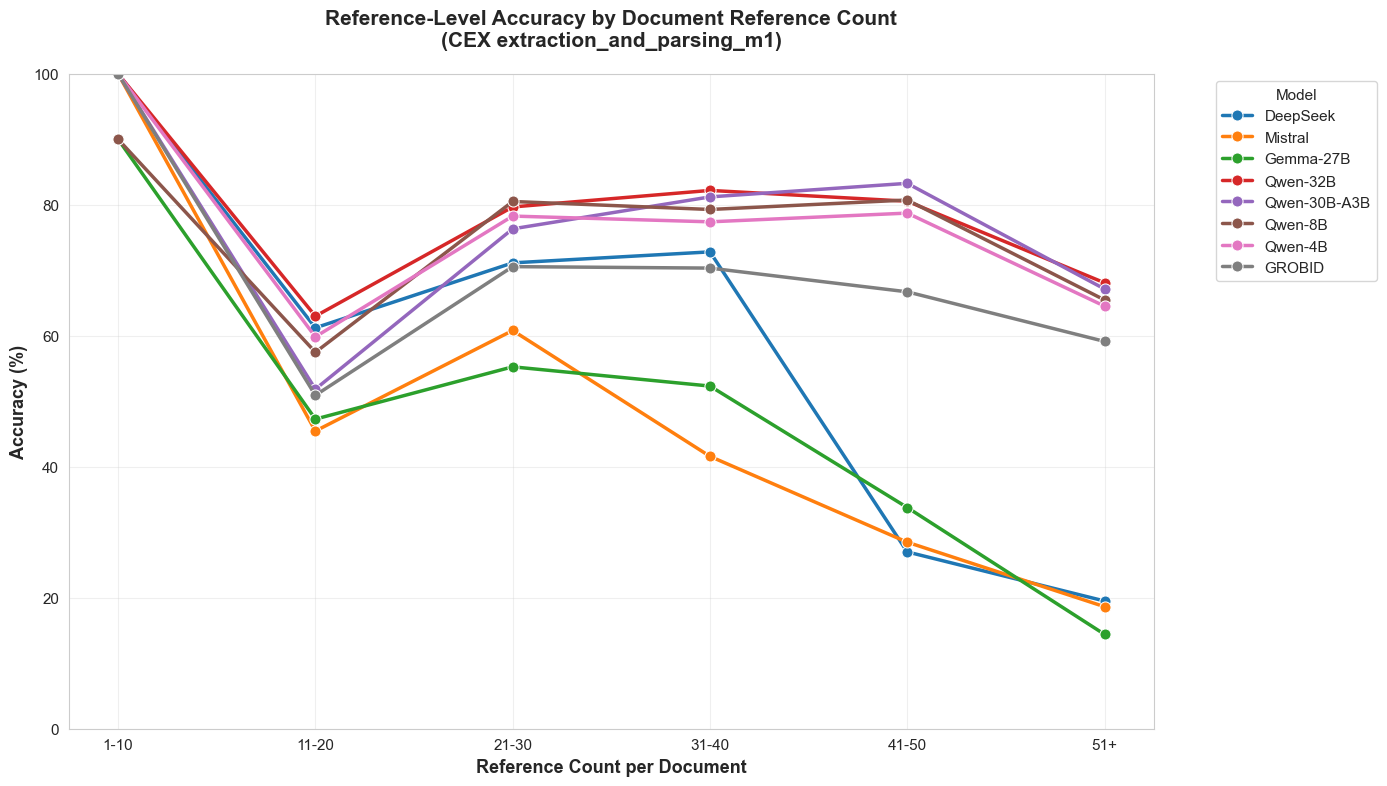


Accuracy by Reference Count Bins:
Ref Bin        1-10  11-20  21-30  31-40  41-50    51+
Model                                                 
DeepSeek      100.0  61.21  71.13  72.81  27.00  19.50
GROBID        100.0  50.91  70.55  70.33  66.71  59.14
Gemma-27B      90.0  47.27  55.26  52.32  33.78  14.41
Mistral       100.0  45.45  60.81  41.59  28.48  18.63
Qwen-30B-A3B  100.0  51.85  76.32  81.20  83.27  67.14
Qwen-32B      100.0  62.99  79.67  82.19  80.55  68.08
Qwen-4B       100.0  59.84  78.27  77.39  78.73  64.52
Qwen-8B        90.0  57.48  80.50  79.28  80.73  65.47


In [12]:
# Calculate accuracy by reference count bins
ref_count_data = []

for model_name, (model_key, df) in zip(model_names, all_models.items()):
    task_df = df[df['task'] == 'extraction_and_parsing'].copy()
    task_df['ref_bin'] = pd.cut(task_df['gt_ref_count'], 
                                 bins=[0, 10, 20, 30, 40, 50, 100],
                                 labels=['1-10', '11-20', '21-30', '31-40', '41-50', '51+'])
    
    bin_stats = task_df.groupby('ref_bin').agg({
        'correct_count': 'sum',
        'gt_ref_count': 'sum'
    })
    bin_stats['Accuracy'] = (bin_stats['correct_count'] / bin_stats['gt_ref_count'] * 100)
    
    for ref_bin, row in bin_stats.iterrows():
        ref_count_data.append({
            'Model': model_name,
            'Ref Bin': ref_bin,
            'Accuracy': row['Accuracy']
        })

ref_count_df = pd.DataFrame(ref_count_data)

# Create line plot using seaborn
fig, ax = plt.subplots(figsize=(14, 8))
sns.lineplot(data=ref_count_df, x='Ref Bin', y='Accuracy', hue='Model', 
             hue_order=model_names,  # Enforce model order in legend
             marker='o', linewidth=2.5, markersize=8, ax=ax, palette='tab10')

ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Reference Count per Document', fontsize=13, fontweight='bold')
ax.set_title('Reference-Level Accuracy by Document Reference Count\n(CEX extraction_and_parsing_m1)', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_ylim(0, 100)
ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/cex/multi_model_comparison/accuracy_by_refcount.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("\nAccuracy by Reference Count Bins:")
pivot_df = ref_count_df.pivot(index='Model', columns='Ref Bin', values='Accuracy')
print(pivot_df.round(2))

## 5. Overall Performance Summary

In [13]:
# Overall statistics comparison
summary_data = []

for model_name, (model_key, df) in zip(model_names, all_models.items()):
    task_df = df[df['task'] == 'extraction_and_parsing']
    total_docs = len(task_df)
    success_docs = len(task_df[task_df['failure_category'] == 'success'])
    total_correct_refs = task_df['correct_count'].sum()
    total_gt_refs = task_df['gt_ref_count'].sum()
    total_minor_errors = task_df['minor_error_count'].sum()
    total_major_errors = task_df['major_error_count'].sum()
    
    summary_data.append({
        'Model': model_name,
        'Total Docs': total_docs,
        'Perfect Docs': success_docs,
        'Doc Success %': (success_docs / total_docs * 100),
        'Total Refs': total_gt_refs,
        'Correct Refs': total_correct_refs,
        'Minor Errors': total_minor_errors,
        'Major Errors': total_major_errors,
        'Ref Accuracy %': (total_correct_refs / total_gt_refs * 100)
    })

summary_df = pd.DataFrame(summary_data).set_index('Model')

print("\n" + "="*80)
print("Overall Performance Summary")
print("="*80)
print(summary_df.round(2))
print("\n" + "="*80)
print(f"Best document-level success: {summary_df['Doc Success %'].idxmax()} ({summary_df['Doc Success %'].max():.2f}%)")
print(f"Best reference-level accuracy: {summary_df['Ref Accuracy %'].idxmax()} ({summary_df['Ref Accuracy %'].max():.2f}%)")
print(f"Lowest minor error rate: {summary_df['Minor Errors'].idxmin()} ({summary_df['Minor Errors'].min()} errors)")
print(f"Lowest major error rate: {summary_df['Major Errors'].idxmin()} ({summary_df['Major Errors'].min()} errors)")
print("="*80)


Overall Performance Summary
              Total Docs  Perfect Docs  Doc Success %  Total Refs  \
Model                                                               
DeepSeek             109             8           7.34        4994   
Mistral              100             7           7.00        4473   
Gemma-27B            112             7           6.25        5161   
Qwen-32B              80             8          10.00        3611   
Qwen-30B-A3B          74             5           6.76        3309   
Qwen-8B               79             7           8.86        3544   
Qwen-4B               73             7           9.59        3248   
GROBID               112             5           4.46        5161   

              Correct Refs  Minor Errors  Major Errors  Ref Accuracy %  
Model                                                                   
DeepSeek              1705           529            55           34.14  
Mistral               1370           594            64       

In [43]:
# UPDATED: Load a model+PDF pickle (benchmarks/cex/outputs)
import os
import json
import pickle
import numpy as np

pkl_path = 'benchmarks/cex/outputs'
task = 'extraction_and_parsing_m1'
model_name = "Qwen3_VL_32B"  # e.g., deepseek, mistral_small, gemma_27b, qwen_32b, grobid
pdf_name = "HEA-PRO_58"  # with or without extension

# Roots to search for pickle artifacts
search_roots = [
    "../cex/outputs",
    # "benchmarks/error_analysis/outputs",
]

pdf_stem = os.path.splitext(pdf_name)[0].lower()
model_key = model_name.lower()


def find_pkls(model_name):
    matches = []
    for root in search_roots:
        if not os.path.exists(root):
            print(f"Directory {root} does not exist")
            continue
        for dirpath, _, filenames in os.walk(root):
            for fname in filenames:
                # end with .pkl, start with task and contain model name
                if fname.endswith('responses.pkl') and fname.startswith(task) and model_name in fname:
                    matches.append(os.path.join(dirpath, fname))
    return matches

def load_pdf_by_id(data, file_id):
    for item in data:
        response = None
        gt_references = None
        if item['file_id'] == file_id:
            response = item['response']
            gt_references = item['gt_references']
            break
    if response is None:
        print(f"No response found for file_id: {file_id}")
        return None
    
    # print the response in json format and gt_references by pair
    response_json = json.loads(response)
    for i, ref in enumerate(response_json['references']):
        print(f"Response {i+1}: {ref}")
        print(f"GT Reference {i+1}: {gt_references[i]}")
        print("\n")
    return None
    
matches = find_pkls(model_name)
   
for p in matches:
    # load the pkl file
    with open(p, 'rb') as f:
        data = pickle.load(f)
        # print the data

load_pdf_by_id(data, pdf_name)



Response 1: {'full_title': 'Exploring physical performance using basic fitness test among adolescent athletes', 'journal_title': 'IJHRS', 'authors': [{'first_name': 'TM', 'middle_name': None, 'surname': 'El-gohary', 'name_link': None, 'role_name': None}, {'first_name': 'AM', 'middle_name': None, 'surname': 'Al-Shenqiti', 'name_link': None, 'role_name': None}, {'first_name': 'MI', 'middle_name': None, 'surname': 'Ibrahim', 'name_link': None, 'role_name': None}, {'first_name': 'et', 'middle_name': None, 'surname': 'al.', 'name_link': None, 'role_name': None}], 'editors': None, 'publisher': None, 'translator': None, 'publication_date': '2019', 'publication_place': None, 'volume': '8', 'issue': None, 'pages': '1–12', 'cited_range': None, 'footnote_number': None}
GT Reference 1: El-gohary TM, Al-Shenqiti AM, Ibrahim MI, et al.: Exploring physical performance using basic fitness test among adolescent athletes. IJHRS, 2019, 8: 1–12. [\[CrossRef\]](http://dx.doi.org/10.5455/ijhrs.0000000163)

